In [30]:
# Cargo las librerías básicas
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# Cargo librerías para el preprocesamiento de datos
from sklearn.model_selection import train_test_split # Dividir los datos en conjuntos de entrenamiento y prueba
from sklearn.preprocessing import StandardScaler # Estandarización de características
from sklearn.impute import SimpleImputer # Manejo de valores faltantes
# Si es necesario, cargo librerías de datasets de ejemplo
#from sklearn.datasets import load_titanic # Dataset del Titanic

# Si es necesario, cargo librerías para la ingeniería de características (Opcional)
from sklearn.preprocessing import OneHotEncoder # Codificación de variables categóricas
# Cargo librerías para la construcción de modelos
from sklearn.tree import DecisionTreeClassifier # Árbol de decisión para clasificación
# Cargo librerías para la evaluación de modelos
from sklearn import metrics # Métricas de evaluación

Variable	Definition	Key
Survived	Survival	
- 0 = No, 1 = Yes
Pclass	Ticket class	
- 1 = 1st, 2 = 2nd, 3 = 3rd
Sex	Sex
Age	Age in years
Sibsp	# of siblings / spouses aboard the Titanic
Parch	# of parents / children aboard the Titanic
Ticket	Ticket number
Fare	Passenger fare
Cabin	Cabin number
Embarked	Port of Embarkation	
- C = Cherbourg, Q = Queenstown,S = Southampton
Pclass: A proxy for socio-economic status (SES)
- 1st = Upper
- 2nd = Middle
- 3rd = Lower

Age: Age is fractional if less than 1. If the age is estimated, is it in the form of xx.5

Sibsp: The dataset defines family relations in this way...
Sibling = brother, sister, stepbrother, stepsister
Spouse = husband, wife (mistresses and fiancés were ignored)

Parch: The dataset defines family relations in this way...
Parent = mother, father
Child = daughter, son, stepdaughter, stepson
Some children travelled only with a nanny, therefore parch=0 for them.

In [6]:
# Obtener el dataset del Titanic
df = pd.read_csv('../datasets/titanic-data.csv', header='infer')

In [13]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


## Procesamiento de datos

### Procesamiento de los valores faltantes (nulos)

In [15]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
dtype: int64

Tratamiento de las edades nulas

In [11]:
# Estrategia para manejar valores faltantes en la columna 'Age'. Rellenar con la media de la columna.
# edad_media = df['Age'].mean()
# df['Age'].fillna(edad_media, inplace=True)

edades = []
for i in range(len(df)):
    if pd.isnull(df.loc[i, 'Age']):
        if ('Mr' in df['Name'][i]) or ('Mrs' in df['Name'][i]):
            edades.append(33) # Edad media aproximada para Mr y Mrs
        else:
            edades.append(10) # Edad media aproximada para Miss        
    else:
        edades.append(df.loc[i, 'Age']) # Mantener la edad original si no es nula
df['Age'] = edades

Tratamiento de los Embarked faltantes

In [14]:
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True) # Rellenar con la moda de la columna 'Embarked'

C:\Users\Fran\AppData\Local\Temp\ipykernel_44948\880485681.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True) # Rellenar con la moda de la columna 'Embarked'


## Estudio de supervivencia

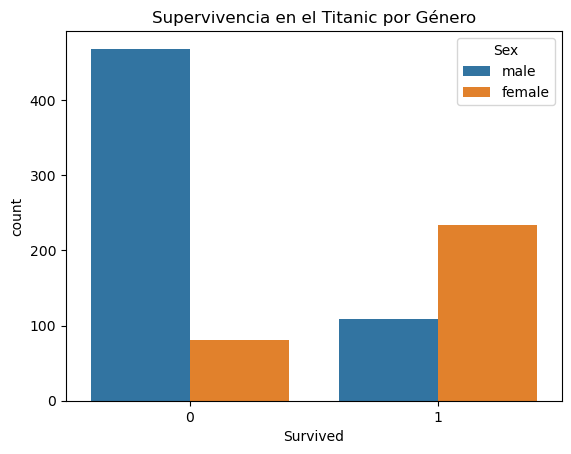

In [ ]:
# Graficar la distribución de supervivencia por género
sns.countplot(x='Survived', data=df, hue='Sex') # Visualizar supervivencia por género
plt.title('Supervivencia en el Titanic por Género')
plt.show()

C:\Users\Fran\AppData\Local\Temp\ipykernel_44948\1632775984.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='EdadCategoria', y='Survived', data=df, ci=None)


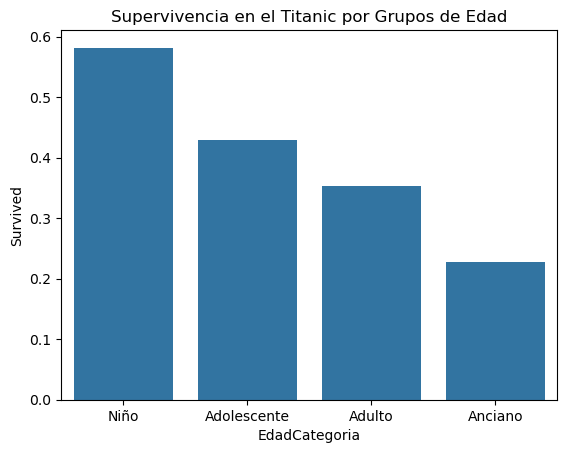

In [19]:
# Graficar la distribución de supervivencia por grupos de edades
df["EdadCategoria"] = pd.cut(df["Age"], bins=[0, 12, 18, 60, 100], labels=["Niño", "Adolescente", "Adulto", "Anciano"])
sns.barplot(x='EdadCategoria', y='Survived', data=df, ci=None)
plt.title('Supervivencia en el Titanic por Grupos de Edad')
plt.show()

C:\Users\Fran\AppData\Local\Temp\ipykernel_44948\3908916897.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='SibSp', y='Survived', data=df, ci=None)


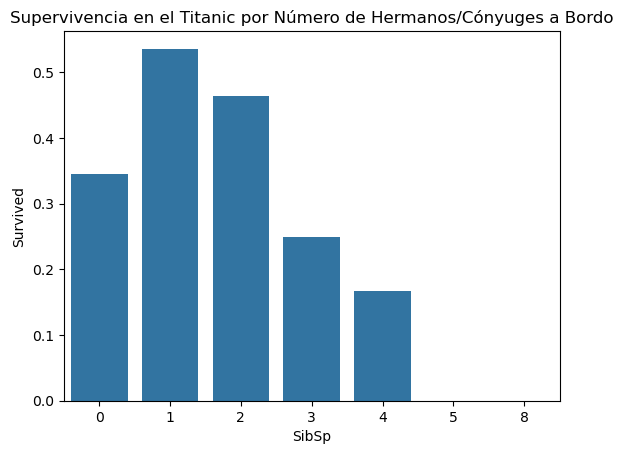

In [20]:
# Supervivencia en el Titanic por número de hermanos/cónyuges a bordo
sns.barplot(x='SibSp', y='Survived', data=df, ci=None)
plt.title('Supervivencia en el Titanic por Número de Hermanos/Cónyuges a Bordo')
plt.show()

## Ingeniería de características

In [21]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,EdadCategoria
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Adulto
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Adulto
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Adulto
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Adulto
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Adulto


Convertir el campo EdadCategoria en múltiples campos booleanos

In [22]:
df = pd.get_dummies(df.EdadCategoria, prefix='EdadCategoria', drop_first=True).join(df.drop(['EdadCategoria','Age'], axis=1)) # One-Hot Encoding de la columna 'EdadCategoria' y eliminar la columna original
df.head()

,EdadCategoria_Adolescente,EdadCategoria_Adulto,EdadCategoria_Anciano,PassengerId,Survived,Pclass,Name,Sex,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,False,True,False,1,0,3,"Braund, Mr. Owen Harris",male,1,0,A/5 21171,7.2500,NaN,S
1,False,True,False,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,1,0,PC 17599,71.2833,C85,C
2,False,True,False,3,1,3,"Heikkinen, Miss. Laina",female,0,0,STON/O2. 3101282,7.9250,NaN,S
3,False,True,False,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,1,0,113803,53.1000,C123,S
4,False,True,False,5,0,3,"Allen, Mr. William Henry",male,0,0,373450,8.0500,NaN,S


In [ ]:
# tratamiento de variables categóricas con One-Hot Encoding
df = pd.get_dummies(df.Sex, prefix='Sex', drop_first=True).join(df.drop('Sex', axis=1)) # One-Hot Encoding de la columna 'Sex' y eliminar la columna original
df = pd.get_dummies(df.Embarked, prefix='Embarked', drop_first=True).join(df.drop('Embarked', axis=1)) # One-Hot Encoding de la columna 'Embarked' y eliminar la columna original
df = pd.get_dummies(df.SibSp, prefix='SibSp', drop_first=True).join(df.drop('SibSp', axis=1)) # One-Hot Encoding de la columna 'SibSp' y eliminar la columna original
df = pd.get_dummies(df.Pclass, prefix='Pclass', drop_first=True).join(df.drop('Pclass', axis=1)) # One-Hot Encoding de la columna 'Pclass' y eliminar
df = pd.get_dummies(df.Parch, prefix='Parch', drop_first=True).join(df.drop('Parch', axis=1)) # One-Hot Encoding de la columna 'Parch' y eliminar la columna original
df.head()


,Parch_1,Parch_2,Parch_3,Parch_4,Parch_5,Parch_6,Pclass_2,Pclass_3,SibSp_1,SibSp_2,...,Sex_male,EdadCategoria_Adolescente,EdadCategoria_Adulto,EdadCategoria_Anciano,PassengerId,Survived,Name,Ticket,Fare,Cabin
0,False,False,False,False,False,False,False,True,True,False,...,True,False,True,False,1,0,"Braund, Mr. Owen Harris",A/5 21171,7.2500,NaN
1,False,False,False,False,False,False,False,False,True,False,...,False,False,True,False,2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",PC 17599,71.2833,C85
2,False,False,False,False,False,False,False,True,False,False,...,False,False,True,False,3,1,"Heikkinen, Miss. Laina",STON/O2. 3101282,7.9250,NaN
3,False,False,False,False,False,False,False,False,True,False,...,False,False,True,False,4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",113803,53.1000,C123
4,False,False,False,False,False,False,False,True,False,False,...,True,False,True,False,5,0,"Allen, Mr. William Henry",373450,8.0500,NaN


In [26]:
# Eliminar columnas innecesarias
df.drop(['PassengerId', 'Name', 'Ticket', 'Cabin', 'Fare'], axis=1, inplace=True)

In [27]:
df.head()

,Parch_1,Parch_2,Parch_3,Parch_4,Parch_5,Parch_6,Pclass_2,Pclass_3,SibSp_1,SibSp_2,...,SibSp_4,SibSp_5,SibSp_8,Embarked_Q,Embarked_S,Sex_male,EdadCategoria_Adolescente,EdadCategoria_Adulto,EdadCategoria_Anciano,Survived
0,False,False,False,False,False,False,False,True,True,False,...,False,False,False,False,True,True,False,True,False,0
1,False,False,False,False,False,False,False,False,True,False,...,False,False,False,False,False,False,False,True,False,1
2,False,False,False,False,False,False,False,True,False,False,...,False,False,False,False,True,False,False,True,False,1
3,False,False,False,False,False,False,False,False,True,False,...,False,False,False,False,True,False,False,True,False,1
4,False,False,False,False,False,False,False,True,False,False,...,False,False,False,False,True,True,False,True,False,0


In [28]:
df.to_csv('../datasets/titanic-data-preprocessed.csv', index=False)

## Predicción de supervivencia

In [31]:
# Elección del modelo
model = DecisionTreeClassifier(random_state=42) # Inicializar el modelo de árbol de decisión
# División de los datos en características (X) y etiqueta (y)
X = df.drop('Survived', axis=1) # Características
y = df['Survived'] # Etiqueta
# División de los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) # 80% entrenamiento, 20% prueba
# Entrenamiento del modelo
model.fit(X_train, y_train)
# Predicción con el modelo entrenado
y_pred = model.predict(X_test)
# Evaluación del modelo
precision = metrics.accuracy_score(y_test, y_pred)
print(f'Precisión del modelo: {precision:.2f}')
print('Matriz de confusión:')
print(metrics.confusion_matrix(y_test, y_pred))
print('Reporte de clasificación:')
print(metrics.classification_report(y_test, y_pred))



Precisión del modelo: 0.82
Matriz de confusión:
[[97  8]
 [24 50]]
Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.80      0.92      0.86       105
           1       0.86      0.68      0.76        74

    accuracy                           0.82       179
   macro avg       0.83      0.80      0.81       179
weighted avg       0.83      0.82      0.82       179



In [32]:
from sklearn.tree import export_text
reglas_arbol = export_text(model, feature_names=list(X.columns))
print("Reglas del Árbol de Decisión:")
print(reglas_arbol)

Reglas del Árbol de Decisión:
|--- Sex_male <= 0.50
|   |--- Pclass_3 <= 0.50
|   |   |--- Parch_2 <= 0.50
|   |   |   |--- Parch_1 <= 0.50
|   |   |   |   |--- Pclass_2 <= 0.50
|   |   |   |   |   |--- Embarked_S <= 0.50
|   |   |   |   |   |   |--- SibSp_1 <= 0.50
|   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |   |--- SibSp_1 >  0.50
|   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |--- Embarked_S >  0.50
|   |   |   |   |   |   |--- class: 1
|   |   |   |   |--- Pclass_2 >  0.50
|   |   |   |   |   |--- SibSp_1 <= 0.50
|   |   |   |   |   |   |--- Embarked_S <= 0.50
|   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |   |--- Embarked_S >  0.50
|   |   |   |   |   |   |   |--- SibSp_2 <= 0.50
|   |   |   |   |   |   |   |   |--- EdadCategoria_Adulto <= 0.50
|   |   |   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |   |   |   |--- EdadCategoria_Adulto >  0.50
|   |   |   |   |   |   |   |   |   |--- SibSp_3 <= 0.50
|   |   |   |   |